In [1]:
from iminuit import Minuit, describe
from scipy.stats import chi2 as chi2_dist
import sys, os
sys.path.append('Utils/')
import matplotlib.pyplot as plt
import numpy as np
# import numpy as np, pymc as pm, aesara.tensor as at
from ExternalFunctions import nice_string_output, add_text_to_ax, Chi2Regression
from PlotUtils import setMplParam, getColour, getHistoParam 
setMplParam()
# taking forever :  40 sec

In [12]:
def gen_lin_data():
    np.random.seed(42)
    x = np.linspace(0, 10, 50)
    y_true = 2 * x + 1
    y = y_true + np.random.normal(0, 1, size=len(x))
    sy = np.ones_like(y)
    return x, y, sy, y_true

def gen_gauss_data():
    np.random.seed(75)
    A_true, mu_true, sg_true = 5.0, 4.5, 1.2
    x = np.linspace(0, 10, 50)
    y_true = A_true * np.exp(-0.5 * ((x - mu_true) / sg_true)**2)
    y = y_true + np.random.normal(0, 0.3, size=len(x))
    sy = 0.3 * np.ones_like(y)
    return x, y, sy, y_true

def gen_mixed_data(
    x_min=0, x_max=10, N=40,
    gaussians=None,       # list of dicts: [{"A":..., "mu":..., "sg":...}, ...]
    linear=None,          # dict: {"a":..., "b":...}
    noise_sigma=0.3,
    seed=None
):
    if seed is not None:
        np.random.seed(seed)

    x = np.linspace(x_min, x_max, N)
    y_true = np.zeros_like(x)

    # Add linear component if requested
    if linear is not None:
        a = linear.get("a", 0.0)
        b = linear.get("b", 0.0)
        y_true += a * x + b

    # Add Gaussian components
    if gaussians is not None:
        for g in gaussians:
            A = g["A"]
            mu = g["mu"]
            sg = g["sg"]
            y_true += A * np.exp(-0.5 * ((x - mu)/sg)**2)

    # Add noise to get data
    y = y_true + np.random.normal(0, noise_sigma, size=len(x))
    sy = np.ones_like(x) * noise_sigma
    return x, y, sy, y_true

In [ ]:
def plot_data():
    x_data, y_data, sigma, y_true = gen_lin_data()

    fig, ax = plt.subplots(figsize=(13, 9))

    # Fit line
    ax.errorbar(x_data, y_data, yerr=sigma, fmt='o', capsize=5, label='Data')
    # ax.plot(x_data, y_true, 'k--', linestyle='', label='True')

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    plt.tight_layout()
    plt.show()


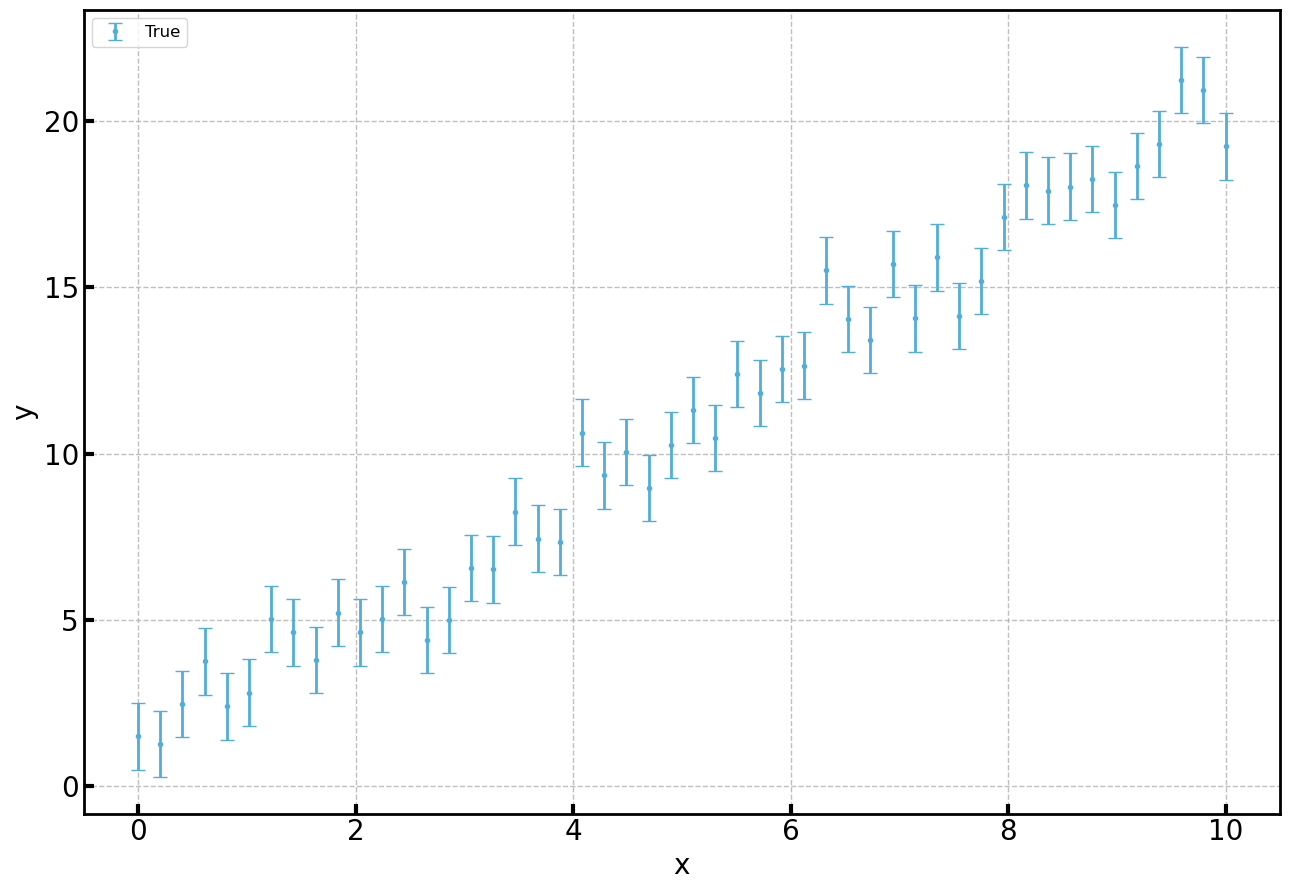

In [24]:
plot_data()

In [ ]:
# Model function SHOULD have signature f(x, a, b)
def lin_model(x, a, b):
    return a * x + b

def gauss_model(x, A, mu, sigma_g):
    return A * np.exp(-0.5 * ((x - mu) / sigma_g)**2)

In [3]:
def optimise(model, x_data, y_data, sigma):
    chi2reg = Chi2Regression(model, x_data, y_data, sy=sigma)

    # Dynamically detect parameter names
    param_names = describe(model)[1:]  # ['a','b'] or ['A','mu','sigma_g']

    # Create initial guesses automatically
    init = {name: 1.0 for name in param_names}

    m = Minuit(chi2reg, **init)
    m.errordef = Minuit.LEAST_SQUARES
    m.migrad()
    m.hesse()

    chi2_min = m.fval
    dof = len(x_data) - len(m.values)
    p_val = 1 - chi2_dist.cdf(chi2_min, dof)

    return m, chi2_min, dof, p_val


In [4]:
def plot_fit(model, gen_fun):
    x_data, y_data, sigma, y_true = gen_fun()
    m, chi2_min, dof, p_val = optimise(model, x_data, y_data, sigma)

    fig, ax = plt.subplots(figsize=(13, 9))
    ax.errorbar(x_data, y_data, yerr=sigma, fmt='o', capsize=5, label='Data')

    # Fit line
    ax.plot(x_data, model(x_data, *m.values), label="Fit")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    # Build stats dictionary
    d = {"N": len(x_data), "dof": dof, "chi²": chi2_min, "p-value": p_val}
    for name in m.parameters:
        d[name] = [m.values[name], m.errors[name]]

    add_text_to_ax(0.02, 0.72, nice_string_output(d, decimals=3), ax,
                   fontsize=14, color='k')
    plt.tight_layout()
    plt.show()


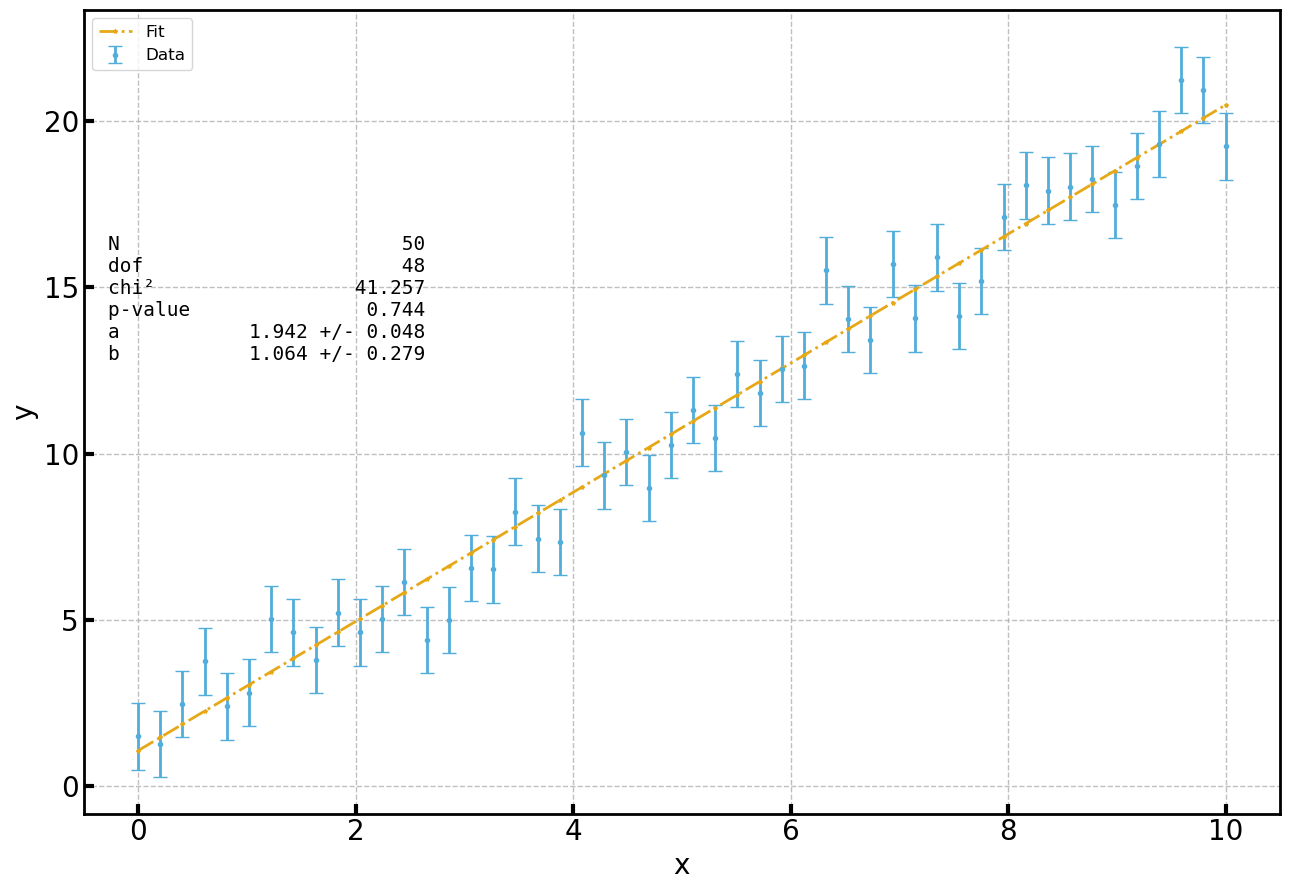

In [5]:
plot_fit(lin_model, gen_lin_data)


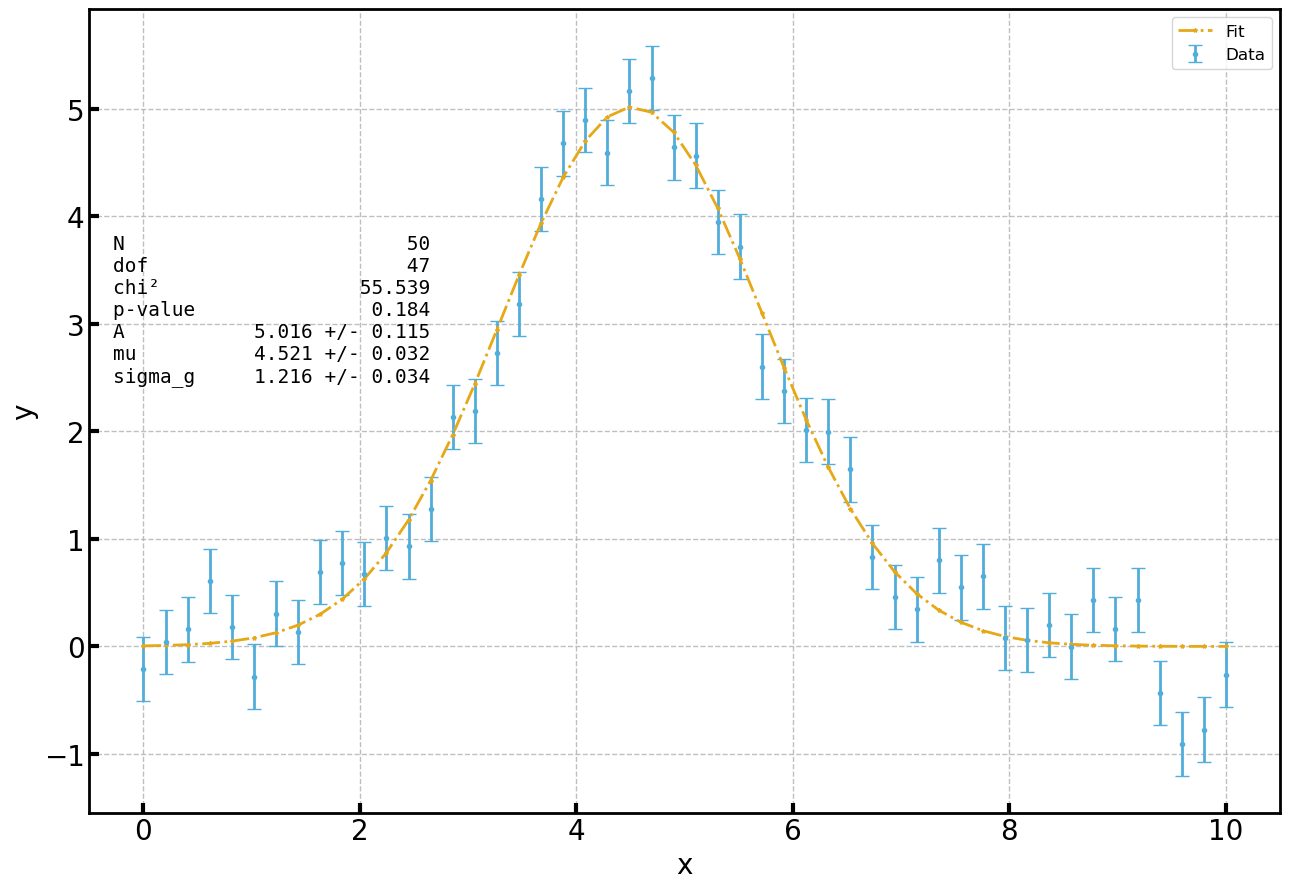

In [6]:
plot_fit(gauss_model, gen_gauss_data)


In [7]:
class CompositeModelFit:
    """
    Fit a sum of component models to a single dataset (x, y, sigma) using Chi2Regression + Minuit.

    - You pass:
        gen_fun: () -> (x_data, y_data, sigma, y_true)   # y_true optional (can be None)
        components: list of callables like [lin_model, gauss_model, ...]
                    each with signature f(x, *params)
                    e.g. lin_model(x, a, b), gauss_model(x, A, mu, sigma_g)
        init_params: dict of initial guesses keyed by auto-generated names
                     Naming rule: every component gets an index suffix 0,1,2,...
                     Example for two gaussians: A0, mu0, sigma_g0, A1, mu1, sigma_g1
                     For one linear: a0, b0

    - What it does:
        * Builds a combined model = sum_i component_i
        * Creates consistent parameter names with indices
        * Runs Minuit with Chi2Regression
        * Plots fit + residuals + stats box (chi², dof, p-value, parameters with errors)
    """

    def __init__(self, gen_fun, components, init_params=None):
        self.gen_fun = gen_fun
        self.components = components
        self.init_params = init_params or {}
        self._prepared = False
        self._fitted = False

    # ---------- plumbing: build parameter namespace and combined model ----------

    def _component_param_names(self, f):
        # First arg is x; the rest are parameter names
        return describe(f)[1:]

    def _prepare(self):
        # Generate data (y_true can be unused)
        out = self.gen_fun()
        if len(out) == 4:
            self.x, self.y, self.sy, self.y_true = out
        else:
            self.x, self.y, self.sy = out
            self.y_true = None

        # Determine parameter names for each component, suffix with index 0..N-1
        self.component_specs = []
        all_param_names = []
        for idx, f in enumerate(self.components):
            base = self._component_param_names(f)  # e.g. ["A","mu","sigma_g"]
            names = [f"{p}{idx}" for p in base]
            self.component_specs.append(
                {"func": f, "base_names": base, "names": names}
            )
            all_param_names.extend(names)

        self.param_names = all_param_names  # global order
        self._prepared = True

    def _combined_model(self, x, *theta):
        """
        Combined model with positional theta matching self.param_names order.
        """
        # Map flat theta list to dict for quick lookup
        p = {name: val for name, val in zip(self.param_names, theta)}
        total = 0.0
        for spec in self.component_specs:
            f = spec["func"]
            names = spec["names"]
            args = [p[name] for name in names]
            total += f(x, *args)
        return total

    # ---------- fitting ----------

    def fit(self):
        if not self._prepared:
            self._prepare()

        # Wrap in Chi2Regression
        chi2reg = Chi2Regression(self._combined_model, self.x, self.y, sy=self.sy)

        # IMPORTANT: override parameter names so Minuit knows them
        chi2reg._parameters = {name: None for name in self.param_names}

        # Build initial guesses, default=1.0 if missing
        init = {name: 1.0 for name in self.param_names}
        init.update(self.init_params)  # user-specified values win

        # Run Minuit
        m = Minuit(chi2reg, **init)
        m.errordef = Minuit.LEAST_SQUARES
        m.migrad()
        m.hesse()

        # Store results
        self.minuit = m
        self.values = {name: m.values[name] for name in self.param_names}
        self.errors = {name: m.errors[name] for name in self.param_names}
        self.chi2 = m.fval
        self.ndof = len(self.x) - len(self.param_names)
        self.p_value = 1 - chi2_dist.cdf(self.chi2, self.ndof)
        self._fitted = True
        return self

    # ---------- plotting ----------

    def _predict(self, x):
        theta = [self.values[name] for name in self.param_names]
        return self._combined_model(x, *theta)

    def plot_fit(self, show_true=False, show_text=True):
        """
        Plot data with fit on top and residuals (y - y_fit) with error bars below.
        """
        if not self._fitted:
            self.fit()

        # Layout: main + residuals
        fig = plt.figure(figsize=(16, 11))
        gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.08)
        ax = fig.add_subplot(gs[0, 0])
        ax_res = fig.add_subplot(gs[1, 0], sharex=ax)

        # Top: data and fit
        ax.errorbar(self.x, self.y, yerr=self.sy, fmt='o', markersize=8,
                    capsize=5, ecolor='k', label='Data')
        y_fit = self._predict(self.x)
        ax.plot(self.x, y_fit, '-', lw=2, label='Fit')

        # if show_true and self.y_true is not None:
        #     ax.plot(self.x, self.y_true, '--', lw=1.5, label='True')

        ax.set_ylabel('y')
        ax.legend(loc='best')

        # Stats box
        if show_text:
            d = {"N": len(self.x), "dof": self.ndof, "chi²": self.chi2, "p-value": self.p_value}
            for name in self.param_names:
                d[name] = [self.values[name], self.errors[name]]
            add_text_to_ax(0.02, 0.98, nice_string_output(d, decimals=3),
                        ax, fontsize=12, color='k')
        else: 
            ax.text(0.05, 0.75, "???", family='monospace', transform=ax.transAxes, fontsize=20)

        # Bottom: residuals
        resid = self.y - y_fit
        ax_res.axhline(0.0, lw=1, color=getColour(1))
        ax_res.errorbar(self.x, resid, yerr=self.sy, fmt='o', markersize=5,
                        capsize=3, ecolor='k')
        ax_res.set_xlabel('x')
        ax_res.set_ylabel('resid')

        # Tidy
        plt.setp(ax.get_xticklabels(), visible=False)
        fig.tight_layout()
        plt.show()


/var/folders/5g/9cr0t2sj5mj8w4wcjj4by3300000gq/T/ipykernel_32650/3751718278.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


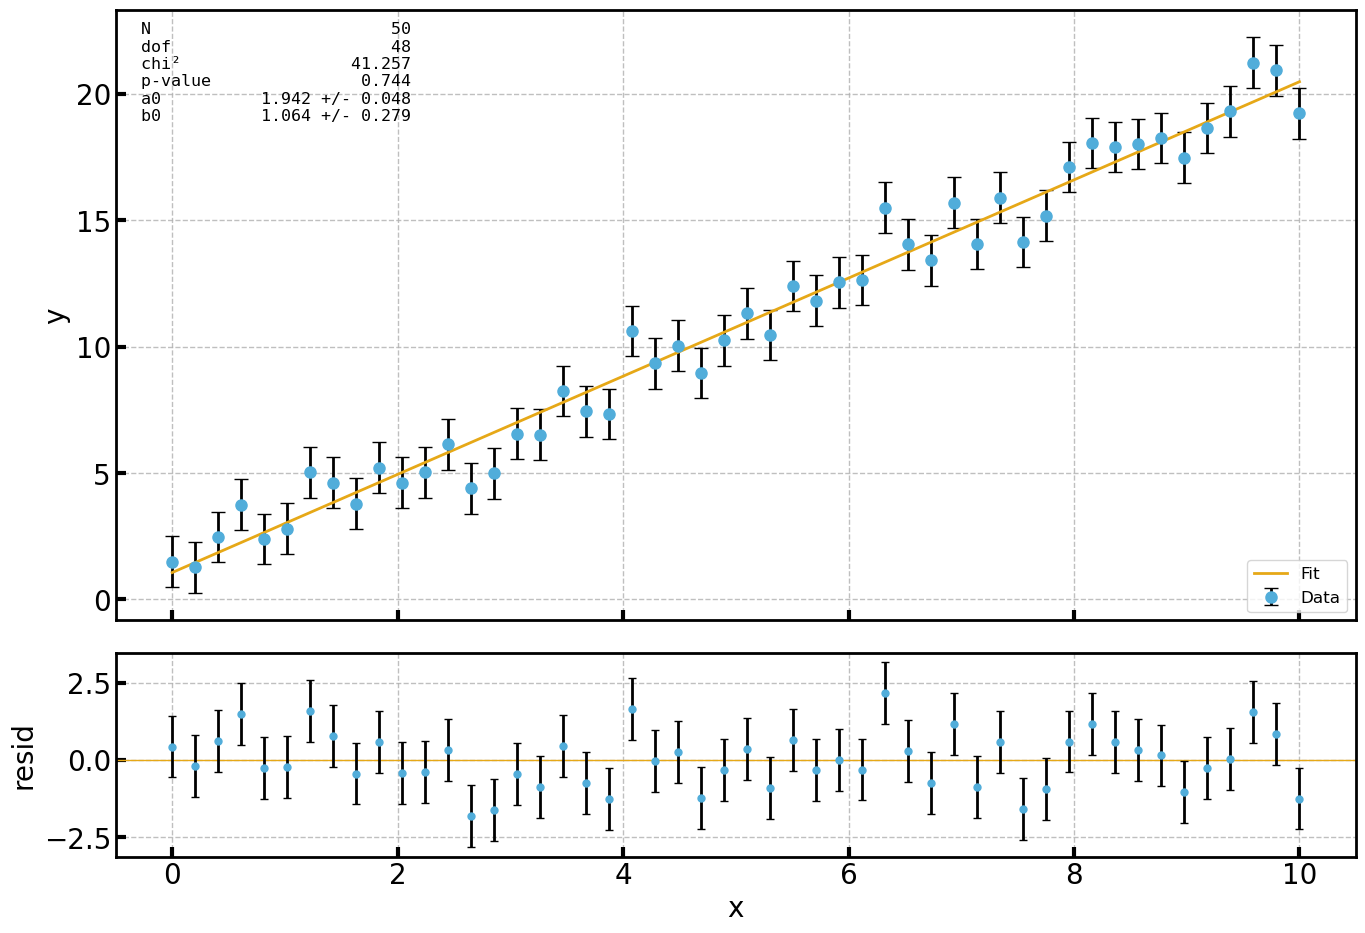

In [8]:
fit_lin = CompositeModelFit(
    gen_fun=gen_lin_data,
    components=[lin_model],
    init_params={"a0": 0.5, "b0": 0.5}  # note the 0 suffix
).fit()
fit_lin.plot_fit(show_text=True)

/var/folders/5g/9cr0t2sj5mj8w4wcjj4by3300000gq/T/ipykernel_32650/3751718278.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


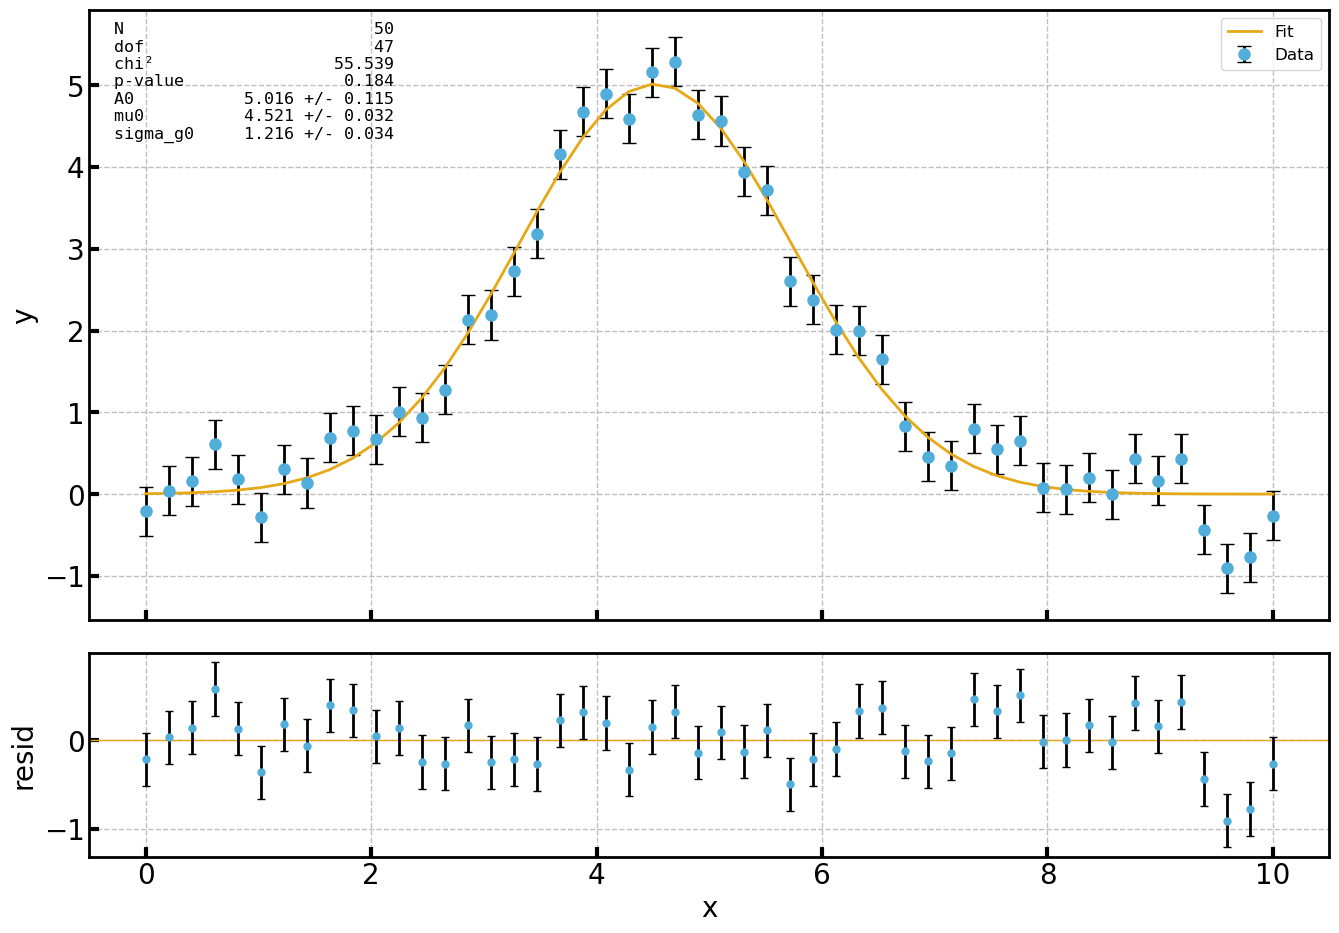

In [9]:
fit_g = CompositeModelFit(
    gen_fun=gen_gauss_data,
    components=[gauss_model],
    init_params={"A0": 4.0, "mu0": 5.0, "sigma_g0": 1.0}
).fit()
fit_g.plot_fit(show_text=True)

/var/folders/5g/9cr0t2sj5mj8w4wcjj4by3300000gq/T/ipykernel_32650/3751718278.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


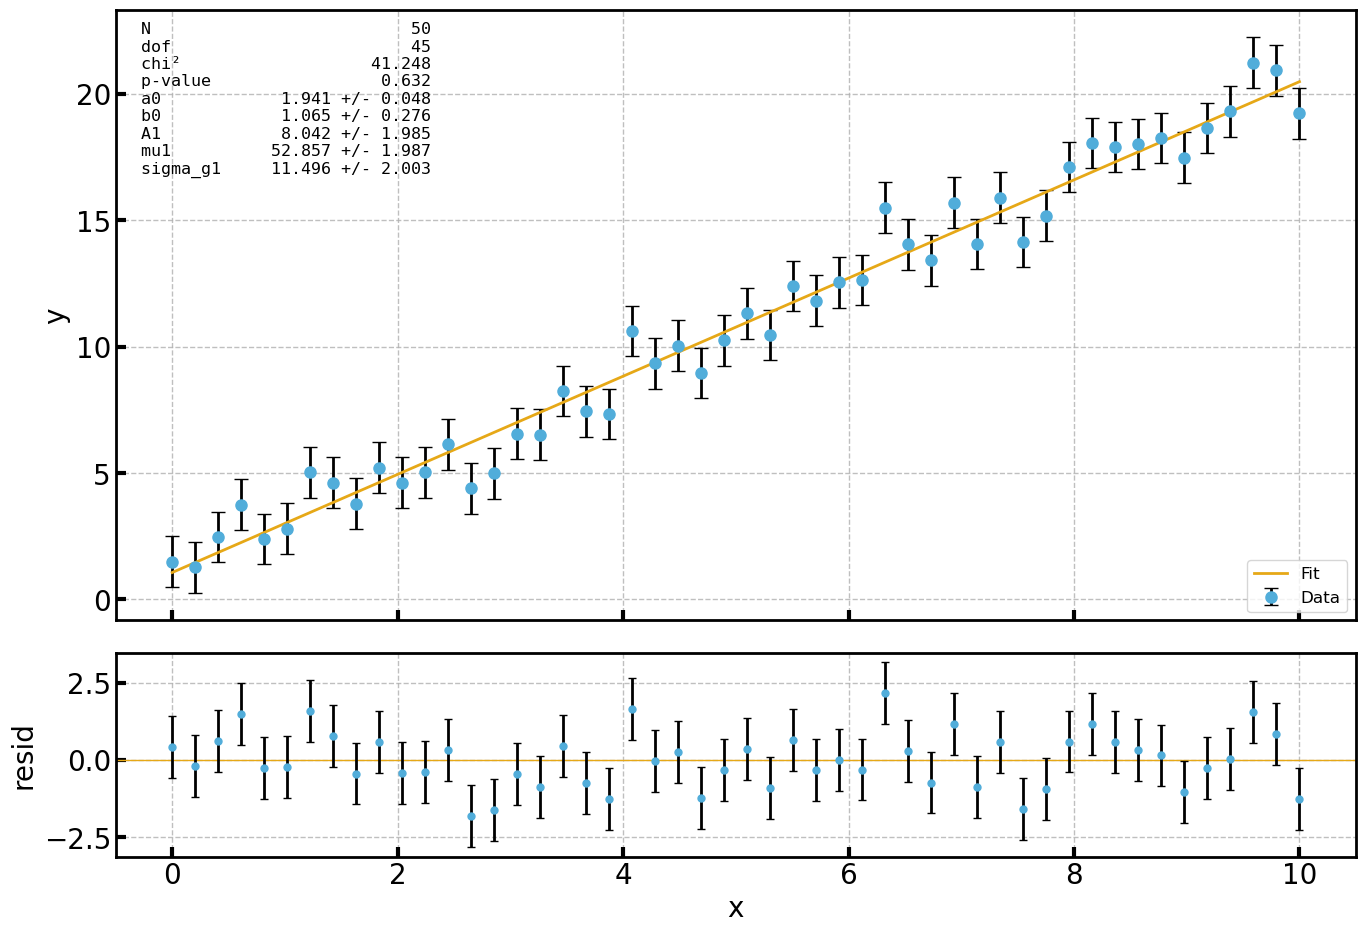

In [10]:
fit_mix = CompositeModelFit(
    gen_fun=gen_lin_data,
    components=[lin_model, gauss_model],
    init_params={
        "a0": 0.3, "b0": 0.2,        # linear(0)
        "A1": 3, "mu1": 5.0, "sigma_g1": 1.0  # gaussian(1)
    }
).fit()
fit_mix.plot_fit(show_text=True)


/var/folders/5g/9cr0t2sj5mj8w4wcjj4by3300000gq/T/ipykernel_32650/3751718278.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


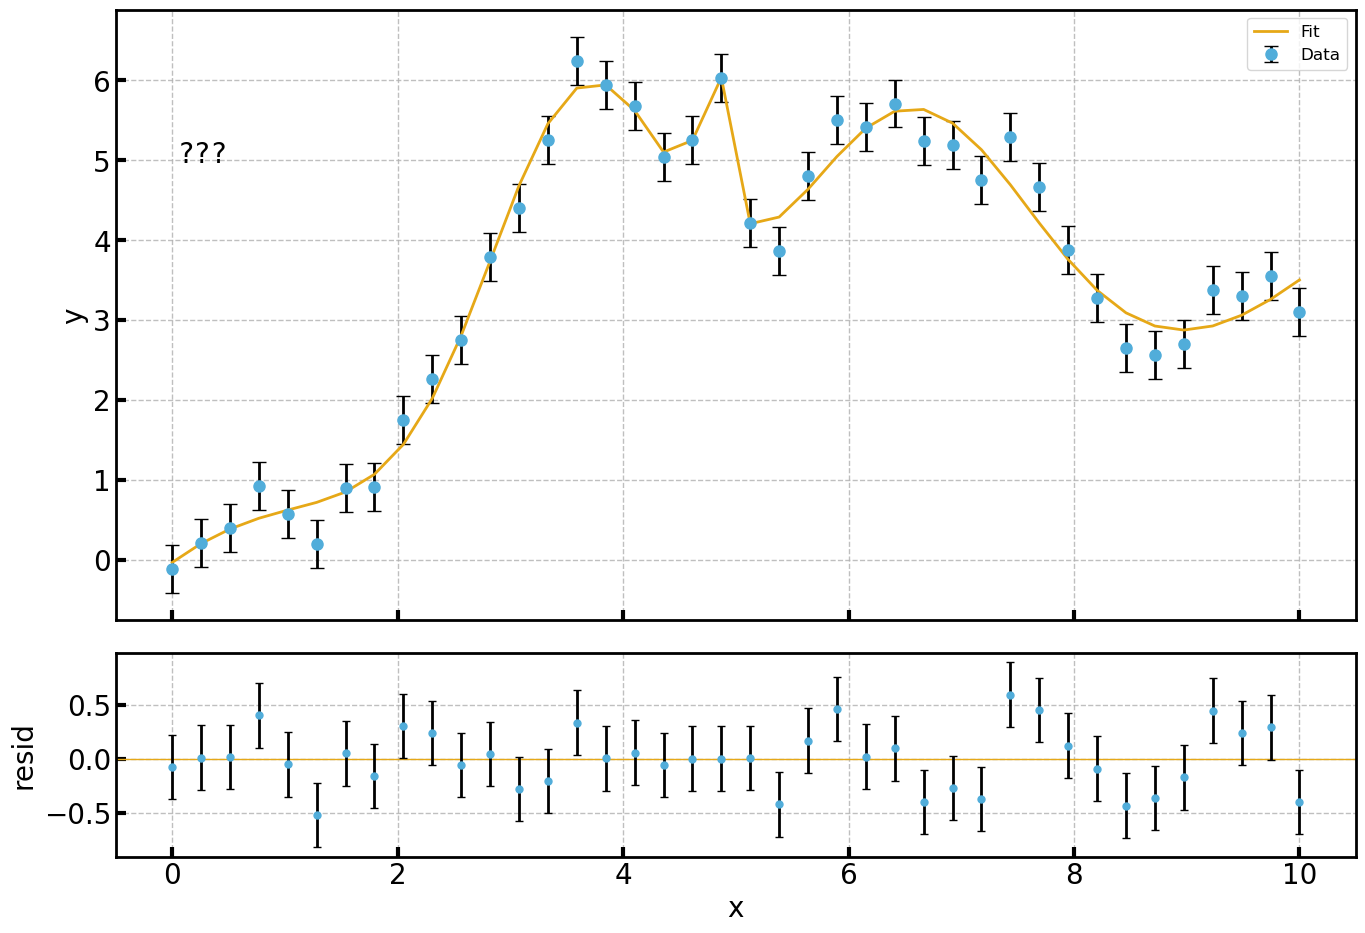

In [11]:
gaussian_params = [
    {"A": 4.0, "mu": 3.7, "sg": 0.8},
    {"A": 1.0, "mu": 4.0, "sg": 1.0},
    {"A": 2.0, "mu": 7.5, "sg": 0.3},
    {"A": 2.0, "mu": 4.8, "sg": 0.1},
    {"A": 3.5, "mu": 6.3, "sg": 0.75},
]

x, y, sy, y_true = gen_mixed_data(
    N=40,
    gaussians=gaussian_params,
    linear={"a": 0.3, "b": 0.1},
    noise_sigma=0.3,
    seed=75
)
fit_5g_lin = CompositeModelFit(
    gen_fun=lambda: (x, y, sy, y_true),
    components=[lin_model] + [gauss_model]*5,
    init_params={
        "a0": 0.1, "b0": 0.1,         # linear component
        "A1": 5.0, "mu1": 4.0, "sigma_g1": 1.5,
        "A2": 3.0, "mu2": 2.0, "sigma_g2": 0.5,
        "A3": 1.5, "mu3": 6.0, "sigma_g3": 0.3,
        "A4": 1.0, "mu4": 3.3, "sigma_g4": 0.1,
        "A5": 2.0, "mu5": 4.8, "sigma_g5": 0.7,
    }
).fit()

fit_5g_lin.plot_fit(show_text=False)

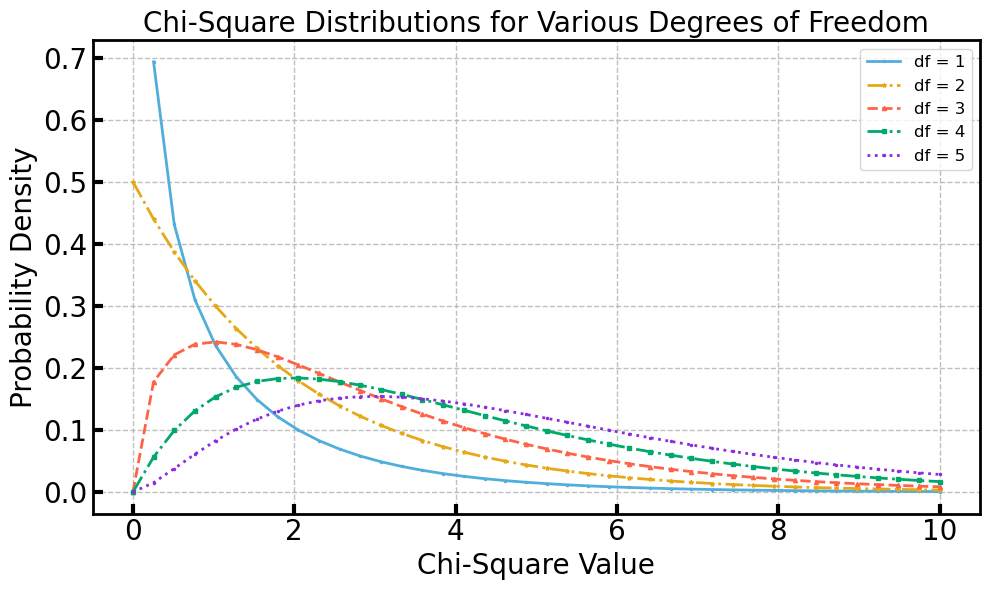

In [27]:
from scipy.stats import chi2

def plot_chi_square_distributions():
    dofs = [1, 2, 3, 4, 5]

    fig, ax = plt.subplots(figsize=(10, 6))

    for dof in dofs:
        pdf = chi2.pdf(x, df=dof)   # probability density function
        ax.plot(x, pdf, label=f'df = {dof}')
        
    ax.set_title('Chi-Square Distributions for Various Degrees of Freedom')
    ax.set_xlabel('Chi-Square Value')
    ax.set_ylabel('Probability Density')
    ax.legend()
    plt.tight_layout()
    plt.show()
plot_chi_square_distributions()